In [1]:
import findspark
findspark.init()

## Module imports

In [2]:
from pyspark.sql.types import *
from pyspark.sql.window import Window
from pyspark.sql.functions import *
from pyspark.sql import DataFrame

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder. \
    appName("pyspark-1"). \
    getOrCreate()

### Read data

In [4]:
df = spark.read.csv("/dataset/nyc-jobs.csv", header=True, inferSchema=True)
df.printSchema()

root
 |-- Job ID: integer (nullable = true)
 |-- Agency: string (nullable = true)
 |-- Posting Type: string (nullable = true)
 |-- # Of Positions: integer (nullable = true)
 |-- Business Title: string (nullable = true)
 |-- Civil Service Title: string (nullable = true)
 |-- Title Code No: string (nullable = true)
 |-- Level: string (nullable = true)
 |-- Job Category: string (nullable = true)
 |-- Full-Time/Part-Time indicator: string (nullable = true)
 |-- Salary Range From: double (nullable = true)
 |-- Salary Range To: double (nullable = true)
 |-- Salary Frequency: string (nullable = true)
 |-- Work Location: string (nullable = true)
 |-- Division/Work Unit: string (nullable = true)
 |-- Job Description: string (nullable = true)
 |-- Minimum Qual Requirements: string (nullable = true)
 |-- Preferred Skills: string (nullable = true)
 |-- Additional Information: string (nullable = true)
 |-- To Apply: string (nullable = true)
 |-- Hours/Shift: string (nullable = true)
 |-- Work Locat

In [5]:
df.show(2, truncate=100)

+------+----------------------------+------------+--------------+----------------------------------------+------------------------------+-------------+-----+------------+-----------------------------+-----------------+---------------+----------------+-------------------+--------------------+----------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------+---------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------+-----------+---------------+-------------------+----------------------------------------------------------------------------------------------------+-------------------------------------------------------------------

In [6]:
df.dtypes

[('Job ID', 'int'),
 ('Agency', 'string'),
 ('Posting Type', 'string'),
 ('# Of Positions', 'int'),
 ('Business Title', 'string'),
 ('Civil Service Title', 'string'),
 ('Title Code No', 'string'),
 ('Level', 'string'),
 ('Job Category', 'string'),
 ('Full-Time/Part-Time indicator', 'string'),
 ('Salary Range From', 'double'),
 ('Salary Range To', 'double'),
 ('Salary Frequency', 'string'),
 ('Work Location', 'string'),
 ('Division/Work Unit', 'string'),
 ('Job Description', 'string'),
 ('Minimum Qual Requirements', 'string'),
 ('Preferred Skills', 'string'),
 ('Additional Information', 'string'),
 ('To Apply', 'string'),
 ('Hours/Shift', 'string'),
 ('Work Location 1', 'string'),
 ('Recruitment Contact', 'string'),
 ('Residency Requirement', 'string'),
 ('Posting Date', 'string'),
 ('Post Until', 'string'),
 ('Posting Updated', 'string'),
 ('Process Date', 'string')]

### Basic data Exploration

#### Infer schema has not been able to get all data types correctly as we can see Date fields are mapped as string. Hence we will enforce a defined schema. we will check sample of values for columns to determine its data type


In [7]:
df.select("Title Code No") \
  .distinct() \
  .show(15)

+-------------+
|Title Code No|
+-------------+
|        70822|
|        80305|
|        31118|
|        52408|
|        50416|
|        52406|
|        82984|
|        51193|
|        22508|
|        34615|
|        91001|
|        52040|
|        34201|
|        1007C|
|        8298A|
+-------------+
only showing top 15 rows



#### Schema definintion

In [8]:
schema = StructType([
    StructField("Job ID", IntegerType(), True),
    StructField("Agency", StringType(), True),
    StructField("Posting Type", StringType(), True),
    StructField("# Of Positions", IntegerType(), True),
    StructField("Business Title", StringType(), True),
    StructField("Civil Service Title", StringType(), True),
    StructField("Title Code No", StringType(), True),
    StructField("Level", StringType(), True),
    StructField("Job Category", StringType(), True),
    StructField("Full-Time/Part-Time indicator", StringType(), True),
    StructField("Salary Range From", DoubleType(), True),
    StructField("Salary Range To", DoubleType(), True),
    StructField("Salary Frequency", StringType(), True),
    StructField("Work Location", StringType(), True),
    StructField("Division/Work Unit", StringType(), True),
    StructField("Job Description", StringType(), True),
    StructField("Minimum Qual Requirements", StringType(), True),
    StructField("Preferred Skills", StringType(), True),
    StructField("Additional Information", StringType(), True),
    StructField("To Apply", StringType(), True),
    StructField("Hours/Shift", StringType(), True),
    StructField("Work Location 1", StringType(), True),
    StructField("Recruitment Contact", StringType(), True),
    StructField("Residency Requirement", StringType(), True),
    StructField("Posting Date", DateType(), True),
    StructField("Post Until", DateType(), True),
    StructField("Posting Updated", DateType(), True),
    StructField("Process Date", DateType(), True)
])

### Read data by enforcing defined schema

In [9]:
df = spark.read.csv(
    "/dataset/nyc-jobs.csv",
    header=True,
    schema=schema,
    sep=",",
    quote='"',
    escape='"',
    multiLine=True
)


In [10]:
print("Rows:", df.count())
print("Columns:", len(df.columns))

Rows: 2946
Columns: 28


#### Check and classify Numerical columns and character columns

In [11]:
numeric_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, (IntegerType, DoubleType))]
categorical_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, StringType)]

print("Numeric Columns:", numeric_cols)
print("Categorical Columns:", categorical_cols)


Numeric Columns: ['Job ID', '# Of Positions', 'Salary Range From', 'Salary Range To']
Categorical Columns: ['Agency', 'Posting Type', 'Business Title', 'Civil Service Title', 'Title Code No', 'Level', 'Job Category', 'Full-Time/Part-Time indicator', 'Salary Frequency', 'Work Location', 'Division/Work Unit', 'Job Description', 'Minimum Qual Requirements', 'Preferred Skills', 'Additional Information', 'To Apply', 'Hours/Shift', 'Work Location 1', 'Recruitment Contact', 'Residency Requirement']


#### Quick overview of numerical columns using describe function (summarizes count, mean, stddev, min , max). We can see below that maximum vacancies among all job titles is 200

In [12]:
#df.describe().show()
df.describe("Salary Range From", "# Of Positions").show()

+-------+-----------------+------------------+
|summary|Salary Range From|    # Of Positions|
+-------+-----------------+------------------+
|  count|             2946|              2946|
|   mean|58904.13979385607|2.4959266802443993|
| stddev|26986.57593579136|  9.28131282646684|
|    min|              0.0|                 1|
|    max|         218587.0|               200|
+-------+-----------------+------------------+



### check for missing values and calculate null percentage

In [13]:
col_nulls = [(c, df.filter(col(c).isNull() | (col(c) == "")).count()/df.count()*100.0) for c in df.columns]

col_nulls

[('Job ID', 0.0),
 ('Agency', 0.0),
 ('Posting Type', 0.0),
 ('# Of Positions', 0.0),
 ('Business Title', 0.0),
 ('Civil Service Title', 0.0),
 ('Title Code No', 0.0),
 ('Level', 0.0),
 ('Job Category', 0.0678886625933469),
 ('Full-Time/Part-Time indicator', 6.619144602851323),
 ('Salary Range From', 0.0),
 ('Salary Range To', 0.0),
 ('Salary Frequency', 0.0),
 ('Work Location', 0.0),
 ('Division/Work Unit', 0.0),
 ('Job Description', 0.0),
 ('Minimum Qual Requirements', 0.6788866259334692),
 ('Preferred Skills', 13.340122199592669),
 ('Additional Information', 37.06720977596741),
 ('To Apply', 0.03394433129667345),
 ('Hours/Shift', 69.99321113374066),
 ('Work Location 1', 53.903598099117445),
 ('Recruitment Contact', 100.0),
 ('Residency Requirement', 0.1357773251866938),
 ('Posting Date', 0.1357773251866938),
 ('Post Until', 70.43448744059742),
 ('Posting Updated', 0.1357773251866938),
 ('Process Date', 0.1357773251866938)]

## Check for KPIs

## 1. calculate number of jobs posting per category (Top 10) 

In [14]:
df.groupBy("Job Category") \
  .count() \
  .orderBy(desc("count")) \
  .limit(10) \
  .show(truncate=False)

+-----------------------------------------+-----+
|Job Category                             |count|
+-----------------------------------------+-----+
|Engineering, Architecture, & Planning    |504  |
|Technology, Data & Innovation            |313  |
|Legal Affairs                            |226  |
|Public Safety, Inspections, & Enforcement|182  |
|Building Operations & Maintenance        |181  |
|Finance, Accounting, & Procurement       |169  |
|Administration & Human Resources         |134  |
|Constituent Services & Community Programs|129  |
|Health                                   |125  |
|Policy, Research & Analysis              |124  |
+-----------------------------------------+-----+



### 2. Salary distribution per job category

In [15]:
df = df.withColumn(
    "mean_salary",
    (col("Salary Range From").cast("double") + 
     col("Salary Range To").cast("double")) / 2
)

df.groupBy("Job Category") \
  .agg(
      avg("mean_salary").alias("avg_salary"),
      min("mean_salary").alias("min_salary"),
      max("mean_salary").alias("max_salary"),
      stddev("mean_salary").alias("salary_stddev")
  ) \
  .orderBy(desc("avg_salary")) \
  .show()

+--------------------+------------------+----------+----------+------------------+
|        Job Category|        avg_salary|min_salary|max_salary|     salary_stddev|
+--------------------+------------------+----------+----------+------------------+
|Administration & ...|          218587.0|  218587.0|  218587.0|               0.0|
|Engineering, Arch...|          198518.0|  198518.0|  198518.0|               0.0|
|Engineering, Arch...|          196042.5|  182500.0|  209585.0|15637.532041001012|
|Health Policy, Re...|          128694.5|   94889.0|  162500.0| 39035.22905017979|
|Engineering, Arch...|          128247.5|  128247.5|  128247.5|               0.0|
|Engineering, Arch...|          128247.5|  128247.5|  128247.5|               0.0|
|Communications & ...|          125000.0|  125000.0|  125000.0|               0.0|
|Administration & ...|          118287.0|  118287.0|  118287.0|               0.0|
|Constituent Servi...|116900.33333333333|   58500.0|  217201.0| 78042.19525530191|
|Con

### 3. correlation between the higher degree (education) and the salary

In [16]:
df = df.withColumn(
    "degree_level",
    when(lower(col("Minimum Qual Requirements")).contains("phd"), 4)
    .when(lower(col("Minimum Qual Requirements")).contains("doctor"), 4)
    .when(lower(col("Minimum Qual Requirements")).contains("master"), 3)
    .when(lower(col("Minimum Qual Requirements")).contains("bachelor"), 2)
    .when(lower(col("Minimum Qual Requirements")).contains("associate"), 1)
    .otherwise(0)
)
# Correlation
correlation = df.stat.corr("degree_level", "mean_salary")
print("Correlation between Degree and Salary:", correlation)




Correlation between Degree and Salary: 0.2679093705677669


## Positive correlation between qualification and salary shows that higher the degree better the salary

### 4. job posting having the highest salary per agency

In [17]:
window_spec = Window.partitionBy("Agency") \
                    .orderBy(desc("mean_salary"))


df.withColumn("rank", row_number().over(window_spec))\
    .filter(col("rank") == 1)\
    .select("Agency", "Job ID", "mean_salary")\
    .show(truncate=False)

+------------------------------+------+-----------+
|Agency                        |Job ID|mean_salary|
+------------------------------+------+-----------+
|LANDMARKS PRESERVATION COMM   |425347|60103.5    |
|OFFICE OF COLLECTIVE BARGAININ|170989|9.555      |
|FIRE DEPARTMENT               |420216|120474.5   |
|ADMIN FOR CHILDREN'S SVCS     |407253|117474.5   |
|MANHATTAN COMMUNITY BOARD #8  |369120|19.0       |
|TAX COMMISSION                |423630|45088.5    |
|HRA/DEPT OF SOCIAL SERVICES   |424997|112527.5   |
|TAXI & LIMOUSINE COMMISSION   |413804|140000.0   |
|EQUAL EMPLOY PRACTICES COMM   |420065|67970.0    |
|DEPARTMENT OF BUSINESS SERV.  |97899 |111377.0   |
|DEPT OF DESIGN & CONSTRUCTION |416442|151795.0   |
|TEACHERS RETIREMENT SYSTEM    |420740|69078.5    |
|DEPARTMENT OF CORRECTION      |423322|137500.0   |
|FINANCIAL INFO SVCS AGENCY    |424356|135000.0   |
|OFFICE OF EMERGENCY MANAGEMENT|417137|70995.0    |
|HOUSING PRESERVATION & DVLPMNT|423210|135000.0   |
|CIVILIAN CO

### 5. job positngs average salary per agency for the last 2 years

In [18]:
max_date = df.select(max(col("Posting Date")).alias("max_date")).collect()[0]["max_date"]

last_2_years = df.filter(
    col("Posting Date") >= add_months(lit(max_date), -24)
)

last_2_years.groupBy("agency") \
    .agg(avg("mean_salary").alias("avg_salary")) \
    .orderBy(desc("avg_salary")) \
    .show()



+--------------------+-----------------+
|              agency|       avg_salary|
+--------------------+-----------------+
|CONFLICTS OF INTE...|         135000.0|
|NYC EMPLOYEES RET...|98336.02777777778|
| BOARD OF CORRECTION|          96222.5|
|FINANCIAL INFO SV...|96021.12903225806|
|DEPT OF DESIGN & ...|87849.33802816902|
|MAYORS OFFICE OF ...|87357.14285714286|
|DEPT OF INFO TECH...|87014.67055555552|
|NYC HOUSING AUTHO...|85801.99691588784|
|NYC DEPT OF VETER...|          82653.0|
|BUSINESS INTEGRIT...|82117.35714285714|
|      LAW DEPARTMENT|81849.09421111112|
|OFFICE OF THE COM...|       80960.3125|
|HOUSING PRESERVAT...|80102.37790697675|
|DEPARTMENT OF FIN...|79593.83333333333|
|DEPARTMENT OF PRO...|74660.03826086957|
|DEPARTMENT OF CIT...| 72984.3111111111|
|    CONSUMER AFFAIRS|72931.30769230769|
|ADMIN FOR CHILDRE...|72548.61943382354|
|DEPT OF ENVIRONME...|72208.92455369257|
|OFFICE OF EMERGEN...|          70995.0|
+--------------------+-----------------+
only showing top

### 6. highest paid skills in the US market

In [19]:
window_spec = Window.partitionBy("Business Title").orderBy(desc("mean_salary"))


df.withColumn("rank", row_number().over(window_spec))\
             .filter(col("rank") == 1)\
             .orderBy(col("mean_salary").desc())\
            .select("Business Title","mean_salary").show(truncate=False)

+------------------------------------------------------------------------+-----------+
|Business Title                                                          |mean_salary|
+------------------------------------------------------------------------+-----------+
|Deputy Commissioner, Bureau of Customer Services                        |218587.0   |
|Deputy Commissioner, Public Information, M-VII                          |217201.0   |
|Deputy Commissioner, Water and Sewer Operations                         |209585.0   |
|Deputy Commissioner, Wastewater Treatment                               |198518.0   |
|Co-Chief Information Officer                                            |191913.0   |
|Assistant Commissioner, Capital Planning & Delivery                     |182500.0   |
|Vice-President for Support Services                                     |180000.0   |
|ADMINISTRATIVE MANAGEMENT AUDITOR                                       |177374.5   |
|Physician, Bureau of Sexually Transmitted 

## Feature engineering techniques

### 1. Imputing missing values for numerical columns

In [20]:
from pyspark.ml.feature import Imputer

def impute_with_mean_mllib(df: DataFrame, columns: list) -> DataFrame:
    imputer = Imputer(
        inputCols=columns,
        outputCols=columns,
        strategy="mean"
    )
    
    model = imputer.fit(df)
    return model.transform(df)


### 2. Bucket salary based on avg/mean of salary range

In [21]:
def add_salary_bucket(df: DataFrame) -> DataFrame:
    df = df.withColumn(
    "mean_salary",
    (col("Salary_Range_From").cast("double") + 
     col("Salary_Range_To").cast("double")) / 2
)
    
    return df.withColumn(
        "salary_bucket",
        when(col("mean_salary") < 50000, "Low")
        .when(col("mean_salary") < 100000, "Medium")
        .otherwise("High")
    )


### 3. Residency requirement

In [22]:
def is_residency_required(df: DataFrame) -> DataFrame:
    
    return df.withColumn(
        "is_residency_required",
        when(lower(col("Residency_Requirement")).contains("residency is required within 90 days"), "required")
        .when(lower(col("Residency_Requirement")).contains("residency is not required"), "Medium")
        .otherwise("unknown")
    )

### Remove unnecessary features (determined based on free text columns)

In [23]:
def remove_unnecessary_features(df: DataFrame) -> DataFrame:
    
    columns_to_drop = [
        "Job Description",
        "Additional Information"
    ]
    
    return df.drop(*columns_to_drop)


### ML Pipeline Execution

In [24]:
import sys
sys.path.append("/app")

from data_cleaning_and_preprocessing import *

df = spark.read.csv(
    "/dataset/nyc-jobs.csv",
    header=True,
    schema=schema,
    sep=",",
    quote='"',
    escape='"',
    multiLine=True
)

numeric_cols = ['Salary_Range_From', 'Salary_Range_To']

df = clean_data(df)
df = preprocess_columns(df)

# Feature engineering
df = impute_with_mean_mllib(df, numeric_cols)
df = add_salary_bucket(df)
df = is_residency_required(df)


# Feature removal
df = remove_unnecessary_features(df)

df.show(5)
df.printSchema()


+------+--------------------+------------+--------------+--------------------+--------------------+-------------+-----+--------------------+-----------------------------+-----------------+---------------+----------------+--------------------+--------------------+--------------------+-------------------------+--------------------+----------------------+--------------------+-----------+--------------------+-------------------+---------------------+------------+----------+---------------+------------+-----------+-------------+---------------------+
|Job_ID|              Agency|Posting_Type|#_Of_Positions|      Business_Title| Civil_Service_Title|Title_Code_No|Level|        Job_Category|Full_Time_Part_Time_indicator|Salary_Range_From|Salary_Range_To|Salary_Frequency|       Work_Location|  Division_Work_Unit|     Job_Description|Minimum_Qual_Requirements|    Preferred_Skills|Additional_Information|            To_Apply|Hours_Shift|     Work_Location_1|Recruitment_Contact|Residency_Requiremen

### Test cases

In [25]:
from test_pipeline import run_all_tests

run_all_tests()

Running Full Pipeline Test...

Pipeline executed successfully!
All tests passed successfully!


### Save processed data

In [26]:
df.write.mode("overwrite").parquet("output/nyc_jobs_processed.parquet")

### Heatmap visualization to check correlation between numerical fields

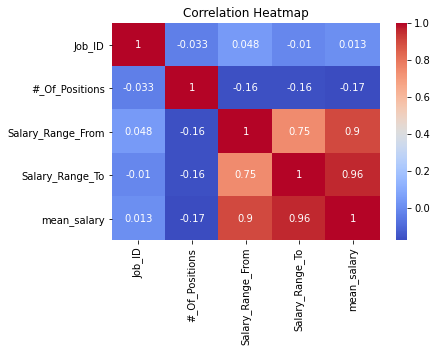

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

pdf = df.toPandas()

corr = pdf.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


### Heatmap doesn't show any correlation except between salary fields

## Deployment suggestion

### If you are looking get the Model gain traction among leadership, it will be faster to productionalize the notebook. The notebook can be triggered as simple as using  Spark-submit command which can be schedule using cron. Once you have the funding to scale the project/model, you can go for cloud services or managed services like Databricks ML and on later stage integrate MLOps to automate deployment.